# Data

## Visualize

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("../../PreviousDataset.csv")
df.shape

(9665, 48)

In [4]:
df.SSTA_Mean.info()

<class 'pandas.core.series.Series'>
RangeIndex: 9665 entries, 0 to 9664
Series name: SSTA_Mean
Non-Null Count  Dtype 
--------------  ----- 
9665 non-null   object
dtypes: object(1)
memory usage: 75.6+ KB


In [242]:
len(df.columns)

48

## Data Cleasing

In [243]:
# coerce numeric columns ที่อาจมี string ปนมา
numeric_cols = ['SSTA', 'ClimSST', 'Depth', 'Longitude_Degrees',
                'Latitude_Degrees', 'Average_Bleaching', 'Windspeed',
                'TSA', 'TSA_DHW', 'SSTA_DHW', 'SSTA_Minimum']

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# parse Date เพื่อใช้กรองปี
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

print(f"Year range: {df['Year'].min():.0f}-{df['Year'].max():.0f}")
print(f"Year distribution:")
print(df['Year'].value_counts().sort_index())

Year range: 1998-2017
Year distribution:
Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
Name: count, dtype: int64


In [244]:
# Step 1: coerce numerics & parse date
numeric_cols = ['SSTA', 'ClimSST', 'Depth', 'Longitude_Degrees',
                'Latitude_Degrees', 'Average_Bleaching', 'Windspeed',
                'TSA', 'TSA_DHW', 'SSTA_DHW', 'SSTA_Minimum']
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

# Step 2: filter rows
df = df[df['SSTA'] > 0]          # remove negative anomalies
df = df[df['Year'] >= 2003]        # remove sparse early years

# Step 3: drop unnecessary columns
drop_cols = ['City_Town', 'City_Town_2', 'City_Town_3', 'Ocean', 'Realm',
             'Ecoregion', 'ID', 'Country_Name', 'State_Island_Province',
             'Date', 'Date2', 'SSTA_Mean', 'Year']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Step 4: ✅ drop ROWS (not columns!) missing key features
features = ['SSTA', 'ClimSST', 'Depth', 'Latitude_Degrees', 'Longitude_Degrees', 'Average_Bleaching']
df = df.dropna(subset=features)   # ← axis=0 (rows) is the default

print(f"Final shape: {df.shape}")  # should be close to (6112, ...)

Final shape: (6112, 36)


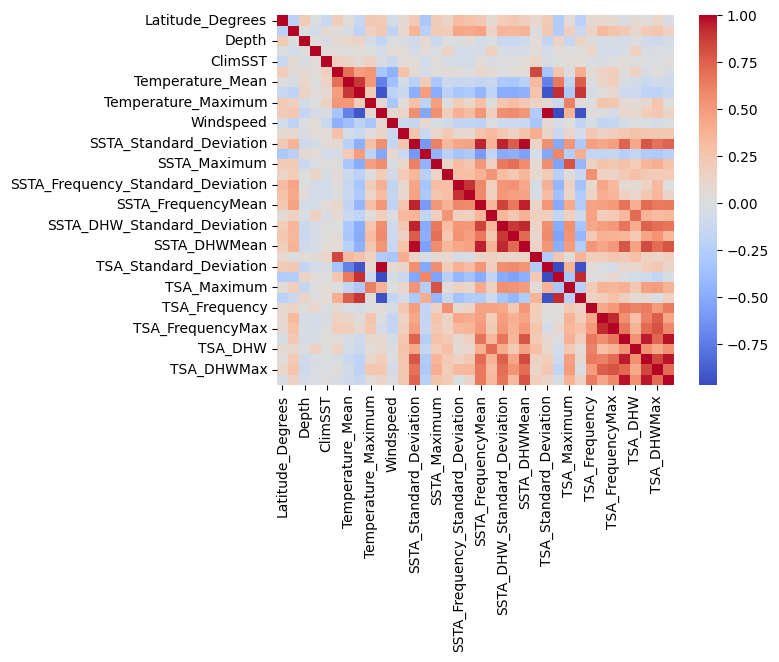

In [245]:
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.show()

# Train

In [246]:
df.Depth

0       4.0
1       5.0
2       6.0
3       5.0
4       2.0
       ... 
9641    3.2
9646    3.0
9649    6.0
9663    9.0
9664    5.0
Name: Depth, Length: 6112, dtype: float64

In [247]:
X = df[['SSTA', 'ClimSST', 'Depth', 'Latitude_Degrees', 'Longitude_Degrees']]
Y = df['Average_Bleaching']

In [248]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [249]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=45)

## Start Train!

In [250]:
model = RandomForestRegressor(
    n_estimators=300, 
    max_depth=16, 
    max_features='sqrt',
    # random_state=42,
    criterion="squared_error"
)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [251]:
# คำนวณ Metric ต่างๆ
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse) # RMSE คือรากที่สองของ MSE

print(f"--- Model Evaluation ---")
print(f"R-squared Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}%")

--- Model Evaluation ---
R-squared Score: 0.2789
Root Mean Squared Error (RMSE): 8.6585%


In [252]:
accuracy_96 = np.mean(np.abs(predictions - y_test) <= 4) * 100
print(f"Tolerance Accuracy (±4%): {accuracy_96:.2f}%")

Tolerance Accuracy (±4%): 80.13%
